# Imports

In [1]:
# Automatically reloads modules before each cell execution, so code changes in library are always propogated.
#reload or load? _ext
%load_ext autoreload
%autoreload 2

%load_ext snakeviz

import networkx as nx
from networkx import MultiDiGraph
import osmnx as ox
import numpy as np
import pandas as pd
from difflib import SequenceMatcher
import concurrent.futures
import copy
import re
from tqdm.notebook import tqdm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.pyplot as plt

from PreProcessing import graph_preprocessing, enrich_attributes
from NetworkOptimisation import graph_optimisation, heuristic
import Plotting

import graph_util as graph_util
import investigation
import constants
import ODGeneration

ox.settings.useful_tags_way = [
    "bridge", "tunnel", "oneway", "lanes", "highway",
     "width", "name", "name:en", "bicycle", "cycleway", "tunnel"]

LOCATION = "Gozo, Malta"
#LOCATION = "Malta (island)"
safe_location = re.sub(r"[()\[\]{}]", "", LOCATION)
safe_location = re.sub(r"[^0-9A-Za-z_-]+", "_", safe_location)
safe_location = re.sub(r"_+", "_", safe_location).strip("_")

GRAPH_PATH = f"../Data/{safe_location}_master_graph.graphml"
SEED = 72
K_SAMPLE = 100 #NOTE TODO 100 preserves rank but for accurate values use 400; k=50 is the lowest acceptable 
N_ITERATIONS = 20 

# Generate and save master graph

Loading OSM networks for Gozo, Malta...
creating master graph network...


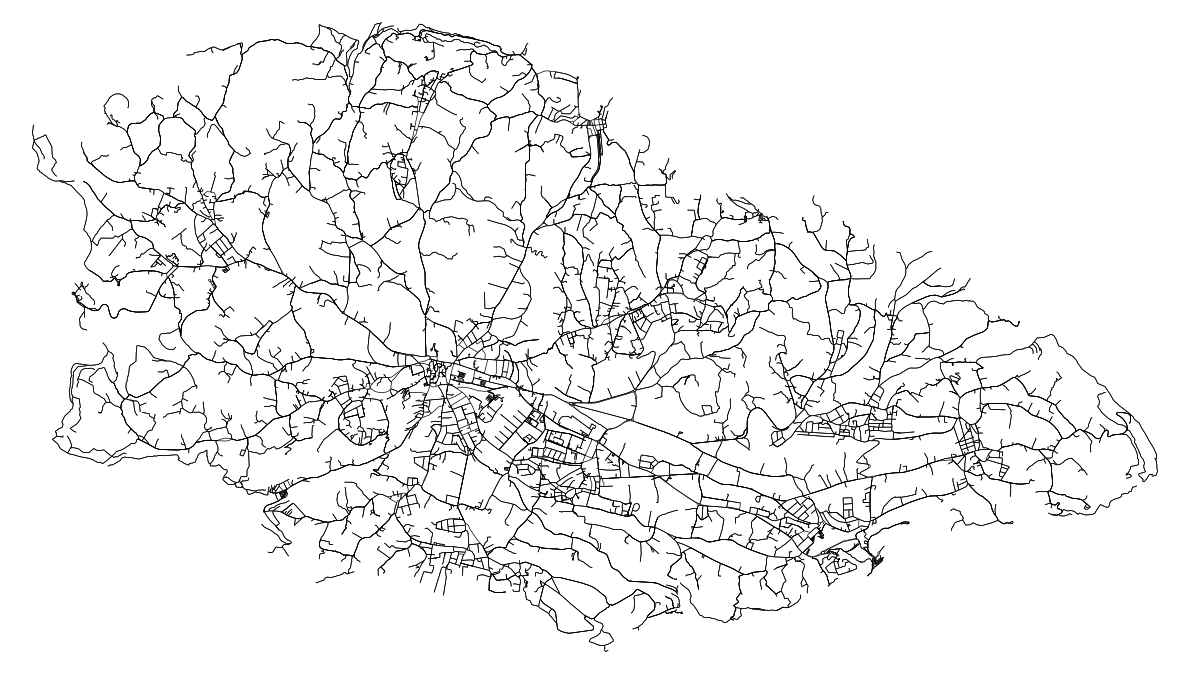

Adding elevation data.....
Imputing missing elevation values
Iteration 1: imputed 29 nodes
Iteration 2: imputed 5 nodes
Iteration 3: imputed 2 nodes
Iteration 4: imputed 0 nodes
Reallocatability summary: [('total', 12415), ('no_car_allowed', 7406), ('reallocatable', 3344), ('no_bike_allowed', 1665)]
Number of localities: 15


In [2]:
#NOTE the length attribute is given in meters
#You project not to fix lengths, but to make sure your geometry math (like areas or spatial intersections) makes sense in linear units.
#Simplify is used to significantly reduce the number of nodes, removing dead ends and combining nodes with no intersections
G_master = graph_preprocessing.load_network(LOCATION)

fig, ax = Plotting.draw_graph(G_master)
ax.axis("off")
fig.tight_layout()
plt.show()

G_master, gdf_regions_proj, gdf_local_proj = graph_preprocessing.clean_graph(G_master, LOCATION)

In [3]:
G_drive = graph_util.make_drive_subgraph(G_master)
enrich_attributes.tag_reallocatable_edges(G_drive)

Counter({'total': 5009, 'reallocatable': 3344, 'no_bike_allowed': 1665})

In [4]:
edges = list(G_master.edges(keys=True, data=True))
u, v, k, data = edges[0]
print(u, v, k)
print(data)

197798 1497329566 0
{'osmid': [139266489, 1182920597], 'oneway': True, 'highway': 'primary', 'name': 'Triq l-Imġarr', 'name:en': 'Mġarr Road', 'reversed': False, 'length': np.float64(8402692.93419991), 'geometry': <LINESTRING (435890.692 3986839.052, 435904.483 3986833.56, 435927.949 39868...>, 'car_allowed': True, 'bike_allowed': False, 'grade': -0.038010328418853705, 'grade_abs': 0.038010328418853705, 'car_lanes': 1, 'bike_lanes': 0, 'infra_type': 'car', 'safety': <SafetyClass.DANGEROUS: 'dangerous'>, 'risk_factor': 4.0, 'reallocatable': False, 'region': 'Reġjun Għawdex', 'locality': 'Għajnsielem'}


In [5]:
graph_util.summarise_road_type_stats(G_master)

Highway type counts:
residential: 5486
track: 1868
service: 1794
tertiary: 1286
primary: 930
secondary: 667
non_motorised: 384
-------
bikeway classification type counts:
None: 11929
yes: 482
permissive: 4
------
cycleway type counts:
None: 12371
no: 44
------
tunnel counts:
None: 12391
yes: 18
building_passage: 6


In [6]:
ox.io.save_graphml(G_master, filepath=GRAPH_PATH)

gdf_local_proj.to_pickle(f"../Data/{safe_location}_gdf_local_proj.pkl")
gdf_regions_proj.to_pickle(f"../Data/{safe_location}_gdf_regions_proj.pkl")

# Load mastergraph

In [7]:
G_master = ox.io.load_graphml(
    filepath=GRAPH_PATH,
    edge_dtypes={
        "car_lanes": int,
        "bike_lanes": int,
        "car_allowed": ox.io._convert_bool_string,
        "bike_allowed": ox.io._convert_bool_string,
        "reallocatable": ox.io._convert_bool_string,
        "grade": float,
        "grade_abs": float,
        "risk_factor": float,
    },
    node_dtypes={
        "elevation": float
    })

gdf_local_proj = pd.read_pickle(f"../Data/{safe_location}_gdf_local_proj.pkl")
gdf_regions_proj = pd.read_pickle(f"../Data/{safe_location}_gdf_regions_proj.pkl")

# Network Inspection

## Road type classification

In [8]:
graph_util.summarise_road_type_stats(G_master)

Highway type counts:
residential: 5486
track: 1868
service: 1794
tertiary: 1286
primary: 930
secondary: 667
non_motorised: 384
-------
bikeway classification type counts:
None: 11929
yes: 482
permissive: 4
------
cycleway type counts:
None: 12371
no: 44
------
tunnel counts:
None: 12391
yes: 18
building_passage: 6


In [9]:
print("Nodes:", G_master.number_of_nodes())
print("Edges (total, counts parallel edges separately):", G_master.number_of_edges())
print(G_master.graph)

Nodes: 4993
Edges (total, counts parallel edges separately): 12415
{'created_date': '2026-01-17 22:23:37', 'created_with': 'OSMnx 2.0.7', 'crs': 'EPSG:32633', 'simplified': True}


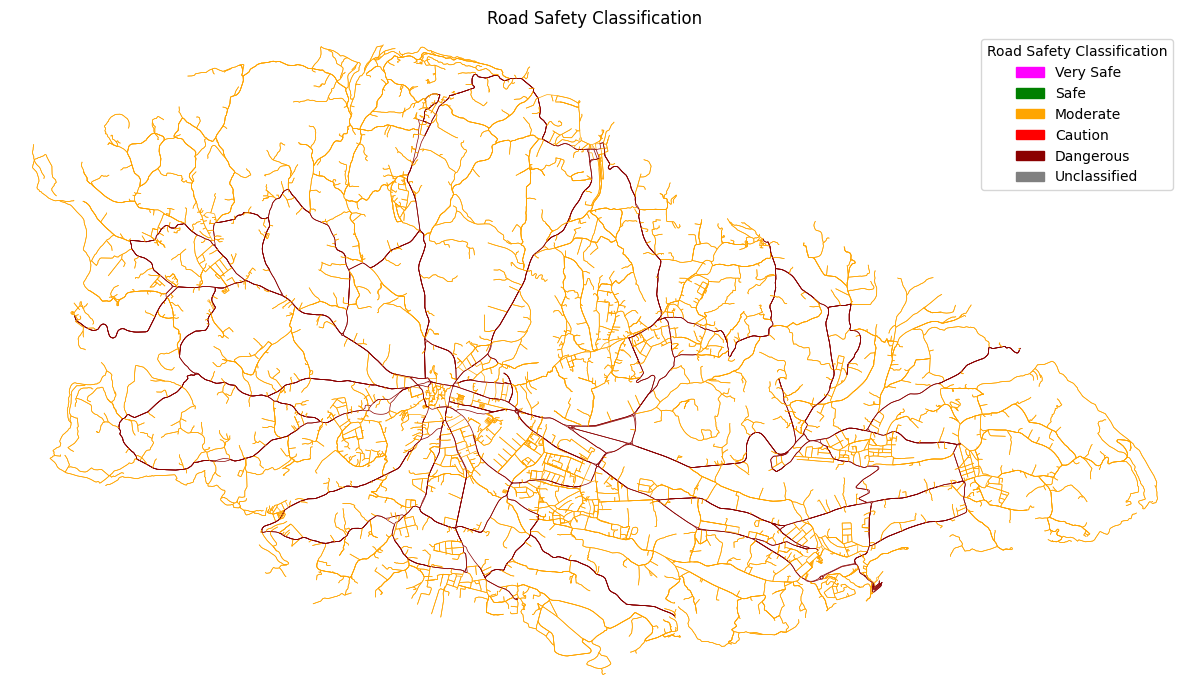

In [10]:
Plotting.plot_safety(G_master)

## Parallel Edges

Directed node pairs: 12315
Pairs with parallel edges (>1): 100
Total extra edges beyond single-edge pairs: 100
Max parallel edges on a single pair: 2

Top pairs by parallel edges:
  (255138121 -> 255138122): 2
  (2667095061 -> 599068672): 2
  (262015684 -> 262015685): 2
  (153211317 -> 2666647165): 2
  (2666647165 -> 153211317): 2
  (2511785737 -> 255442806): 2
  (9088984481 -> 9088984481): 2
  (261695745 -> 261695746): 2
  (261695746 -> 261695745): 2
  (261694600 -> 261694669): 2

Distribution (parallel_count -> number of (u,v) pairs):
  1: 12215
  2: 100
Parallel edge attribute comparison:
  different_highway_only        : 26
  same_highway_and_cycleway     : 170
  different_cycleway_only       : 4


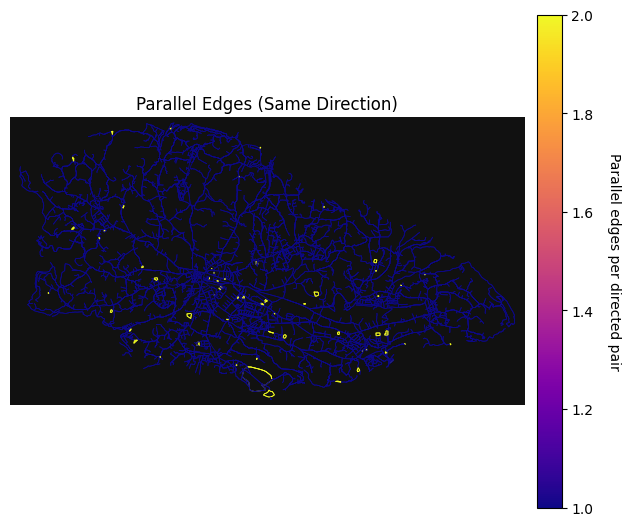

-----


In [11]:
investigation.analyze_parallel_edges(G_master)
investigation.compare_parallel_edges(G_master)
investigation.plot_parallel_edges(G_master) #TODO plotting class
print("-----")

## Reallocatability

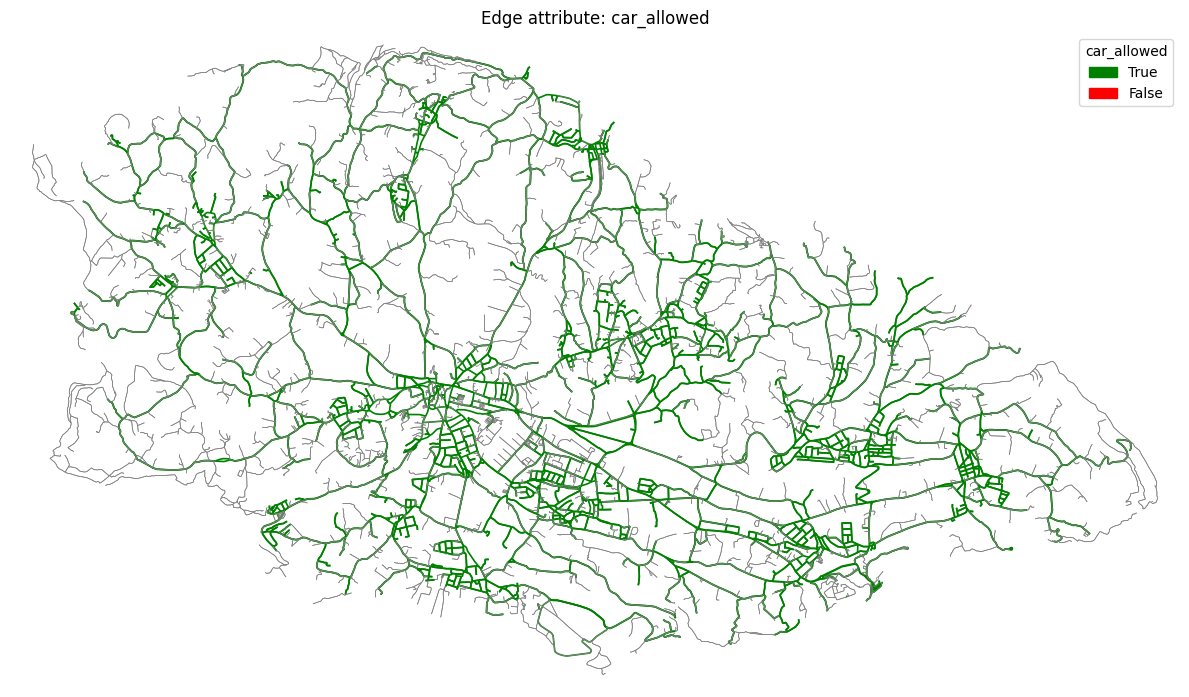

In [12]:
Plotting.plot_boolean_attribute(G_master, "car_allowed")

In [13]:
bridges = set(nx.bridges(G_master.to_undirected()))
print(len(bridges), "actual num might be double actually")

1804 actual num might be double actually


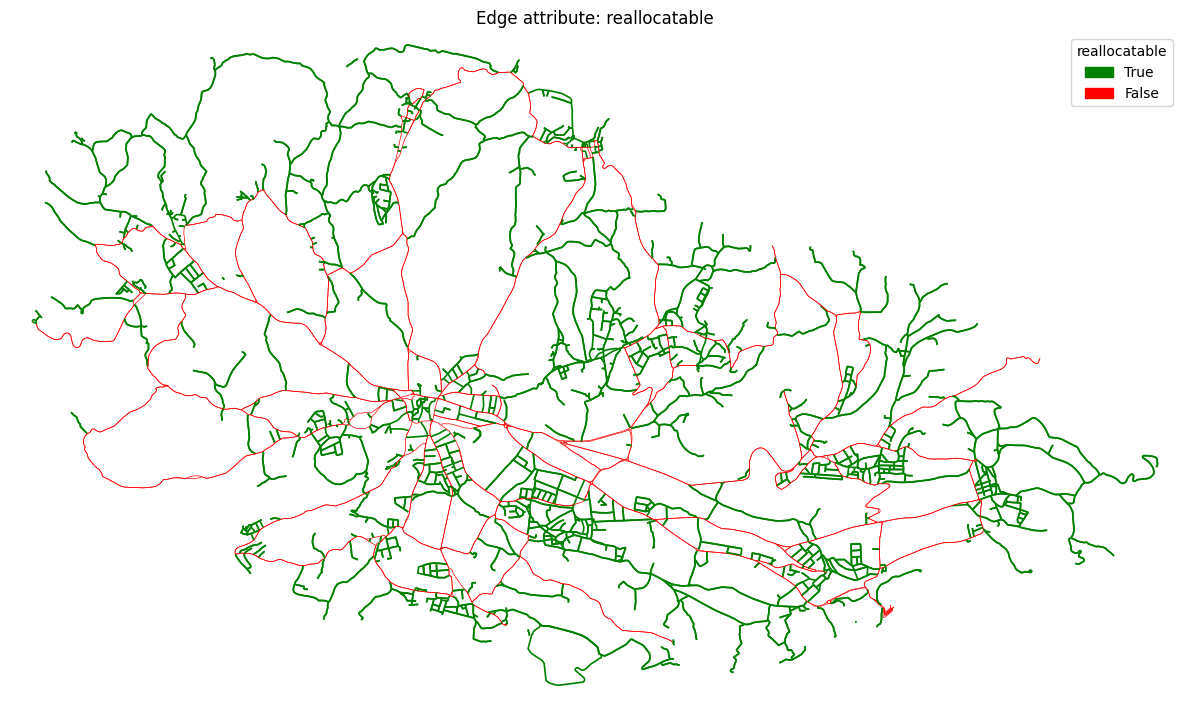

In [14]:
G_drive = graph_util.make_drive_subgraph(G_master)
Plotting.plot_boolean_attribute(G_drive, "reallocatable")

In [15]:
reallocatable_false = 0
reallocatable_true =0
for u, v, k, d in G_drive.edges(keys=True, data=True):
    if d.get("reallocatable"):
        reallocatable_true += 1
    else:
        reallocatable_false += 1

print(f"realloacable true: {reallocatable_true},", f"realloaclable false {reallocatable_false},", f"{reallocatable_true/(reallocatable_true+reallocatable_false)*100}% are reallocable")

realloacable true: 3344, realloaclable false 1665, 66.75983230185666% are reallocable


## Topology

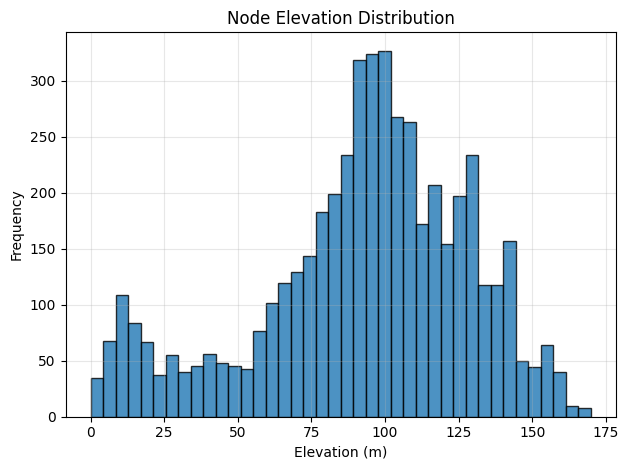

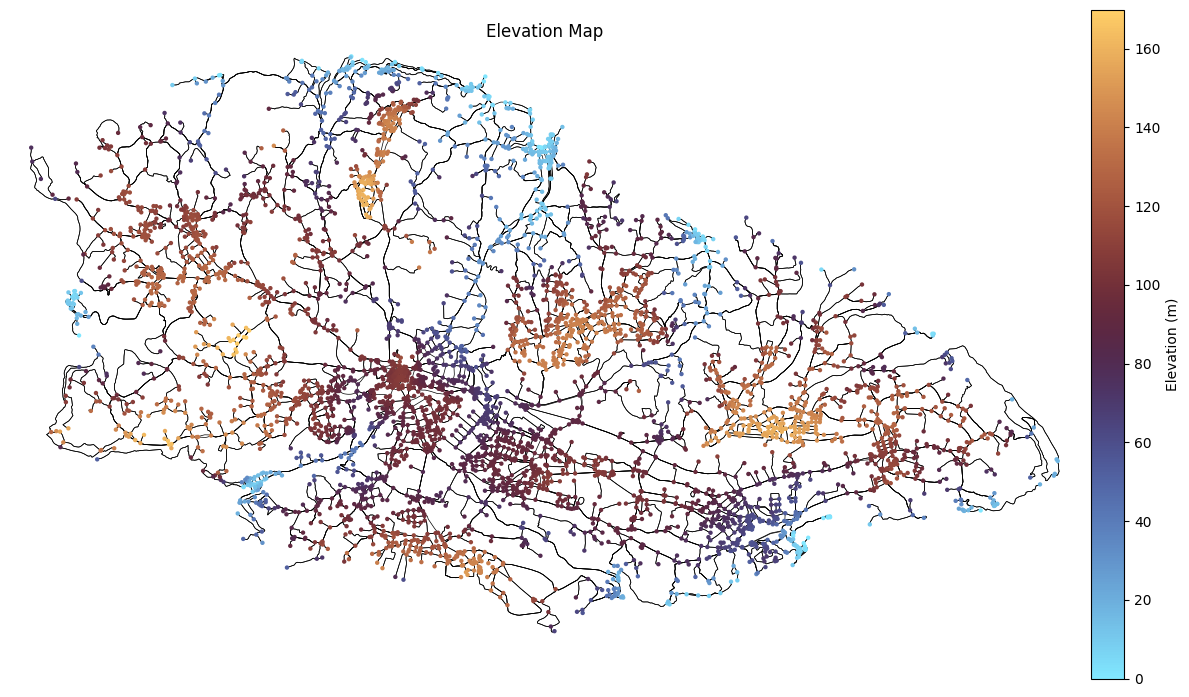

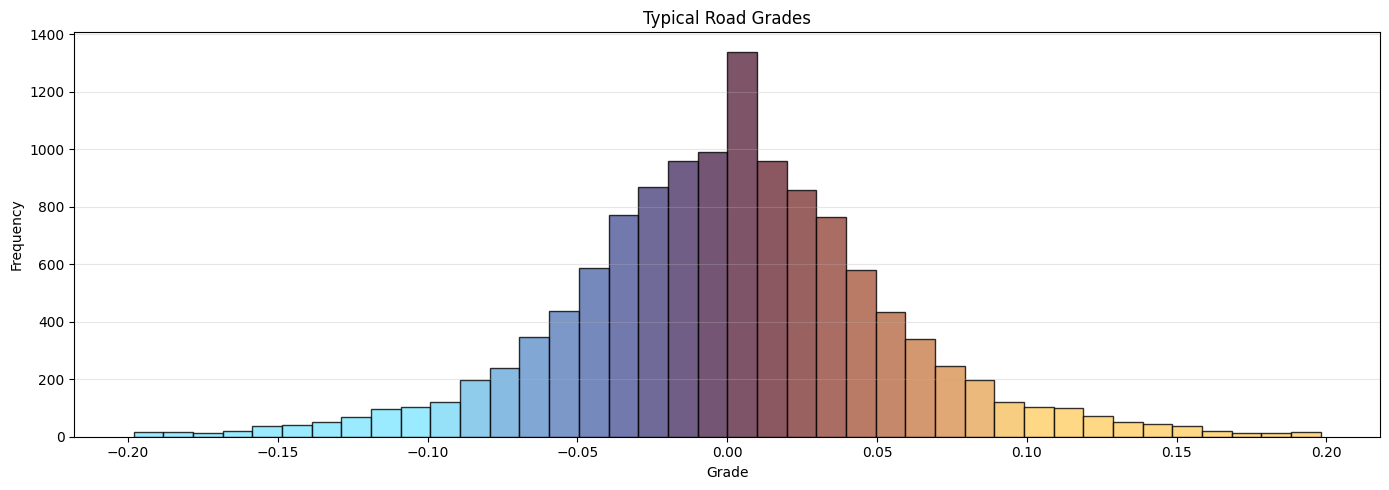

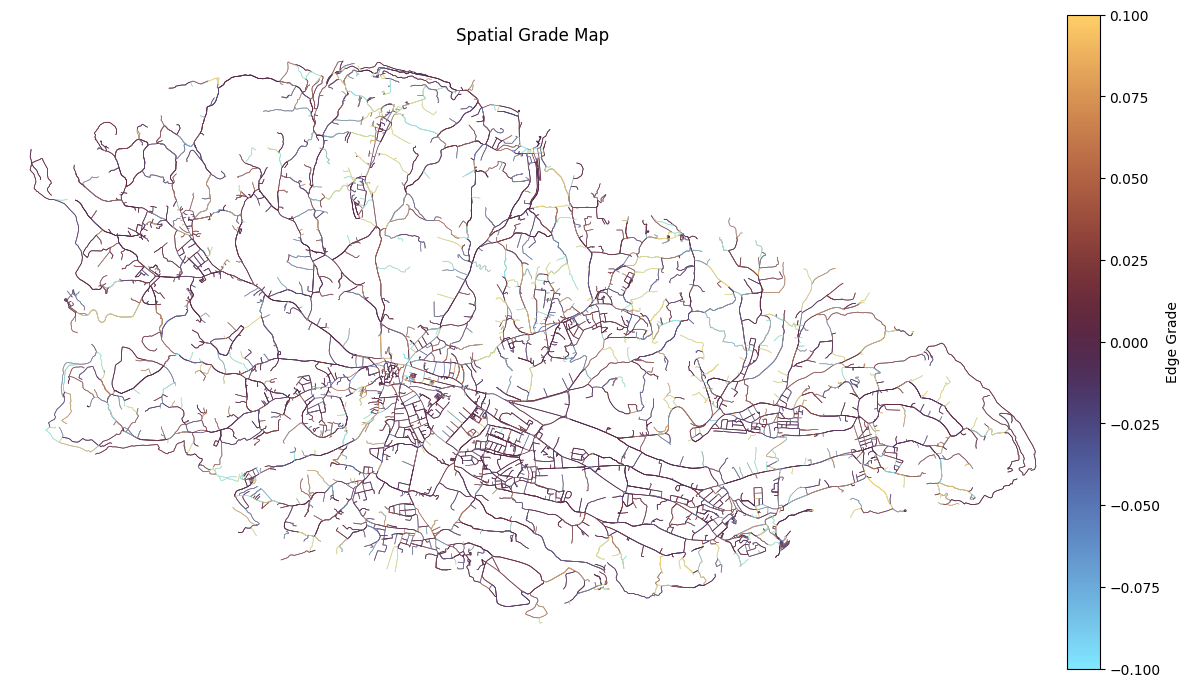

In [16]:
Plotting.plot_elevation(G_master)
Plotting.plot_grades(G_master)

## Network statistics

In [17]:
"""# what sized area does our network cover in square meters?
bike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes
graph_area_m = bike_nodes_proj.union_all().convex_hull.area
# show some basic stats about the network
stats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)"""

'# what sized area does our network cover in square meters?\nbike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes\ngraph_area_m = bike_nodes_proj.union_all().convex_hull.area\n# show some basic stats about the network\nstats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)'

In [18]:
edge_keys = set()
for u,v,data in G_master.edges(data=True):
    edge_keys.update(data.keys())
print(edge_keys)

{'bike_lanes', 'locality', 'car_lanes', 'region', 'cycleway', 'osmid', 'parallel_count', 'width', 'name', 'infra_type', 'oneway', 'name:en', 'geometry', 'tunnel', 'safety', 'bike_allowed', 'length', 'car_allowed', 'risk_factor', 'reallocatable', 'grade', 'bridge', 'grade_abs', 'reversed', 'bicycle', 'highway'}


# Generating city level subgraphs

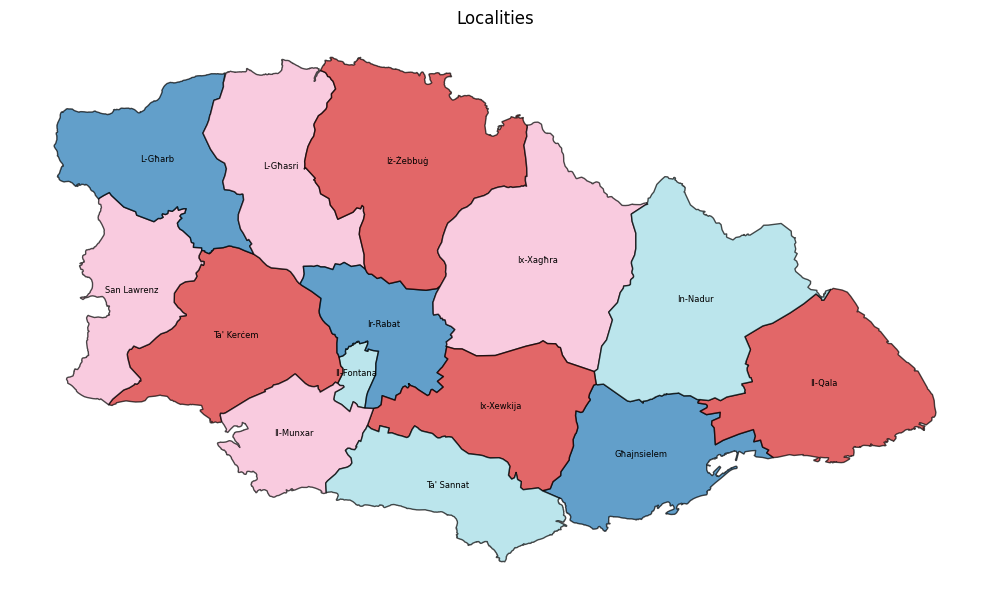

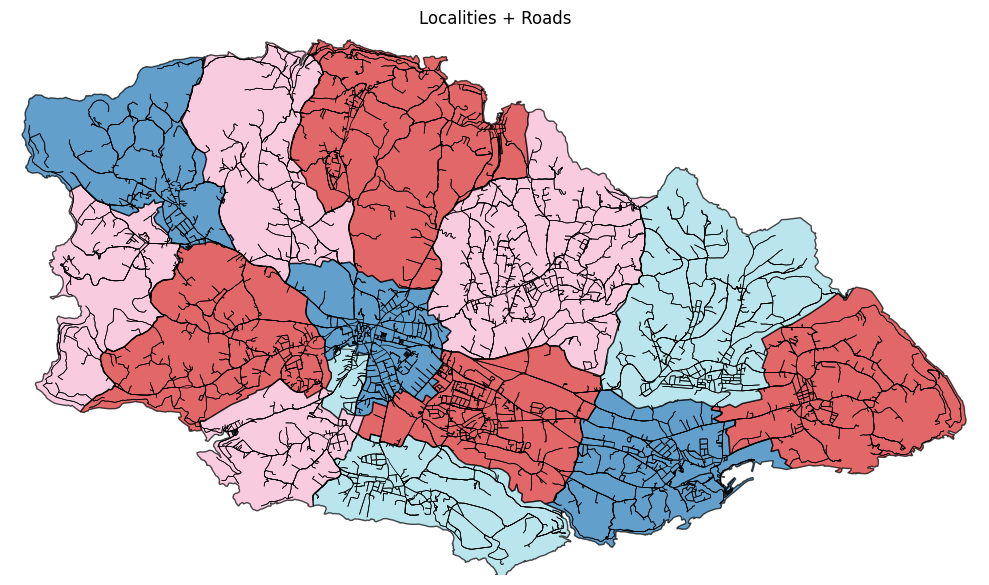

name admin_level  \
element  id                                 
relation 6311965  Għajnsielem           8   
         7508578   Il-Fontana           8   
         7508579   Ta' Kerċem           8   
         7508580  San Lawrenz           8   
         7508581      L-Għarb           8   
         7508582     L-Għasri           8   
         7508583     Ir-Rabat           8   
         7508584    Iż-Żebbuġ           8   
         7508585    Ix-Xagħra           8   
         7508586      Il-Qala           8   
         7508587     In-Nadur           8   
         7508588   Ix-Xewkija           8   
         7508589    Il-Munxar           8   
         7508590   Ta' Sannat           8   

                                                           geometry  color_id  \
element  id                                                                     
relation 6311965  POLYGON ((434495.638 3987046.719, 434497.589 3...         0   
         7508578  POLYGON ((430892.855 3988249.578, 430973.212 3...         3   
         7508579  POLYGON ((427320.748 3987916.19, 427383.682 39...         1   
         7508580  POLYGON ((427164.934 3991122.717, 427175.377 3...         2   
         7508581  POLYGON ((427164.934 3991122.717, 427138.724 3...         0   
         7508582  POLYGON ((429109.074 3992939.259, 429121.724 3...         2   
         7508583  POLYGON ((430307.991 3989805.365, 430356.354 3...         0   
         7508584  POLYGON ((430624.436 3993126.262, 430637.147 3...         1   
         7508585  POLYGON ((432492.258 3989768.61, 432577.988 39...         2   
         7508586  POLYGON ((436673.753 3987981.88, 436774.042 39...         1   
         7508587  POLYGON ((434891.936 3988432.795, 434945.042 3...         3   
         7508588  POLYGON ((431356.709 3987593.652, 431451.982 3...         1   
         7508589  POLYGON ((429084.517 3987652.785, 429073.779 3...         2   
         7508590  POLYGON ((430714.318 3986543.836, 430705.986 3...         3   

                    color  
element  id                
relation 6311965  #1f77b4  
         7508578  #9edae5  
         7508579  #d62728  
         7508580  #f7b6d2  
         7508581  #1f77b4  
         7508582  #f7b6d2  
         7508583  #1f77b4  
         7508584  #d62728  
         7508585  #f7b6d2  
         7508586  #d62728  
         7508587  #9edae5  
         7508588  #d62728  
         7508589  #f7b6d2  
         7508590  #9edae5

In [19]:
#Plotting.plot_gdf_and_overlay(gdf_regions_proj, "Regions", annotate=True)

Plotting.plot_gdf_and_overlay(gdf_local_proj, title = "Localities", annotate=True)
Plotting.plot_gdf_and_overlay(gdf_local_proj, title="Localities + Roads", G=G_master, annotate=False)

In [20]:
subgraphs = {}
total_nodes = 0
total_edges = 0
for idx, row in gdf_local_proj.iterrows():
    name = row["name"]

    G_sub = graph_util.make_locality_subgraph(G_master, name)
    subgraphs[name] = G_sub
    total_nodes += len(G_sub.nodes)
    total_edges += len(G_sub.edges)
    print(f"✅ Created subgraph for {name}: {len(G_sub.nodes)} nodes, {len(G_sub.edges)} edges")

print(f"total_nodes{total_nodes}, total_edges{total_edges}")

✅ Created subgraph for Għajnsielem: 444 nodes, 1089 edges
✅ Created subgraph for Il-Fontana: 78 nodes, 158 edges
✅ Created subgraph for Ta' Kerċem: 412 nodes, 924 edges
✅ Created subgraph for San Lawrenz: 186 nodes, 393 edges
✅ Created subgraph for L-Għarb: 262 nodes, 595 edges
✅ Created subgraph for L-Għasri: 246 nodes, 533 edges
✅ Created subgraph for Ir-Rabat: 604 nodes, 1389 edges
✅ Created subgraph for Iż-Żebbuġ: 543 nodes, 1276 edges
✅ Created subgraph for Ix-Xagħra: 637 nodes, 1546 edges
✅ Created subgraph for Il-Qala: 361 nodes, 844 edges
✅ Created subgraph for In-Nadur: 397 nodes, 1022 edges
✅ Created subgraph for Ix-Xewkija: 587 nodes, 1484 edges
✅ Created subgraph for Il-Munxar: 212 nodes, 495 edges
✅ Created subgraph for Ta' Sannat: 274 nodes, 667 edges
total_nodes5243, total_edges12415


# Topological Metrics

Evaluating how good a network is

In [21]:
# Directness - measures how efficiently users can travel between two point

# Centrality
#network_evaluation(graph_util.make_protected_subgraph(G_master))
## Degree - number of connections per node

# Optimisation Approaches 

## Heuristic Approaches

Centrality - betweeness and closeness

the relative ordering of nodes (or edges) is virtually identical.

Relative error → Measures absolute value difference (how far are the actual numbers).

Correlation (or Spearman’s ρ) → Measures rank consistency (how well the ordering is preserved

4993


k samples:   0%|          | 0/5 [00:00<?, ?k/s]

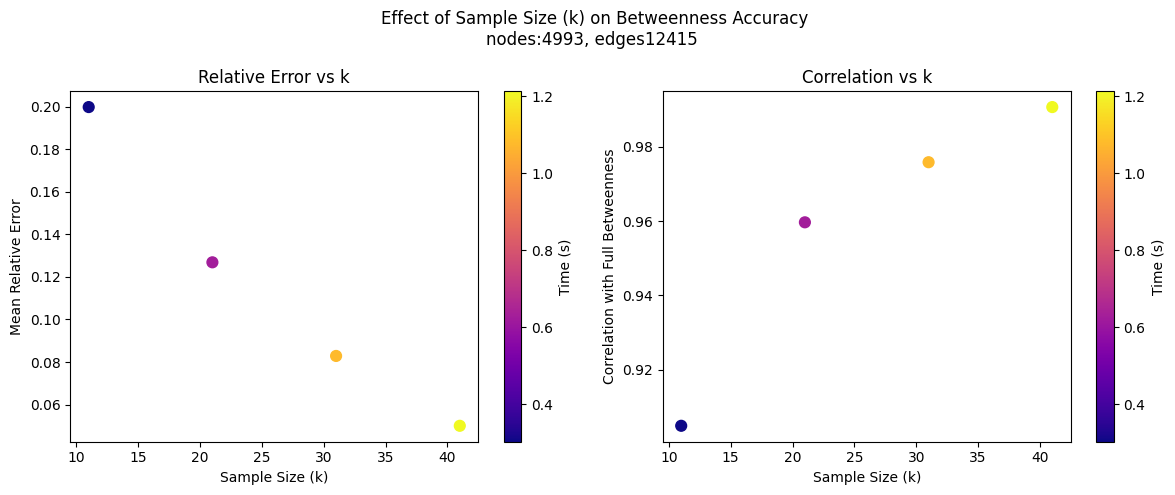

In [22]:
import time
from matplotlib import pyplot as plt
from networkx import DiGraph

#TODO move to own class?
def investigate_k_diff(G:DiGraph, max_k = None, seed=42, step=50):
    if max_k == None:
        max_k = len(G.nodes)

    edges = len(G.edges)
    #TODO this really should be k=NONE
    true_bc = nx.betweenness_centrality(G, weight="length", normalized=True, k=max_k, seed=seed)

    results = []
    iterable = range(1, max_k, step)
    for k in tqdm(iterable, desc="k samples", unit="k"):
        t0 = time.perf_counter()
        approx_bc = nx.betweenness_centrality(G, weight="length", normalized=True, k=k, seed=seed)
        elapsed = time.perf_counter() - t0

        # convert to arrays for shared nodes
        true_vals = np.array([true_bc[n] for n in G.nodes])
        approx_vals = np.array([approx_bc[n] for n in G.nodes])

        # relative mean absolute error
        rel_err = np.mean(np.abs(approx_vals - true_vals) / (true_vals + 1e-9))
        # correlation
        corr = np.corrcoef(true_vals, approx_vals)[0, 1]

        results.append((k, rel_err, corr, elapsed))
        #print(f"k={k:>5} | rel_err={rel_err:.3f} | corr={corr:.3f} | time={elapsed:.2f}s")

    ks, rel_errs, corrs, times = zip(*results)

    #TODO plotting?
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    scatter1 = ax[0].scatter(ks, rel_errs, c=times, cmap="plasma", s=60)
    ax[0].set_title("Relative Error vs k")
    ax[0].set_xlabel("Sample Size (k)")
    ax[0].set_ylabel("Mean Relative Error")
    cbar = plt.colorbar(scatter1, ax=ax[0]); cbar.set_label("Time (s)")

    scatter2 = ax[1].scatter(ks, corrs, c=times, cmap="plasma", s=60)
    ax[1].set_title("Correlation vs k")
    ax[1].set_xlabel("Sample Size (k)")
    ax[1].set_ylabel("Correlation with Full Betweenness")
    cbar2 = plt.colorbar(scatter2, ax=ax[1]); cbar2.set_label("Time (s)")

    plt.suptitle(f"Effect of Sample Size (k) on Betweenness Accuracy\nnodes:{len(G.nodes)}, edges{edges} ")
    plt.tight_layout()
    plt.show()

print(len(G_master.nodes))
investigate_k_diff(G_master,max_k=50, seed=12, step=10)

In [23]:
#%snakeviz -t
#TODO getting new very safe edges even tho nothing got allocated?
heuristics = {
    "L2S": heuristic.heuristic_L2S,
    #"CC": heuristic.heuristic_CC,
    #"L2C": heuristic.heuristic_L2C,
    #"R2C": heuristic.heuristic_R2C,
    #"Random": heuristic.heuristic_random,
    #"edge_betweenness": heuristic.heuristic_edge_betweenness_centrality,
    #"edge_closeness_centrality": heuristic.heuristic_edge_closeness_centrality,
}

chosen_localities = {"Birkirkara", "Il-Birgu"}  # use set for fast membership
subgraphs = {name: G for name, G in subgraphs.items() if name in chosen_localities}

#NOTE majority of computation time is spent on evaluation 
all_results = []
for name, func in heuristics.items():
    print(f"Running {name} heuristic")
    df = graph_optimisation.run_global(
        G_master,
        heuristic_func=func,
        n_iterations=100,
        max_workers=7,
        EVALUATION_MOD=1,
        k_sample = 25, 
        parallel=False,
    )
    df["heuristic"] = name
    all_results.append(df)

optimised_graph_results_df = pd.concat(all_results, ignore_index=True)
optimised_graph_results_df.sort_values(by=["heuristic", "locality", "iteration"])
optimised_graph_results_df.head()

Running L2S heuristic


Processing localities:   0%|          | 0/1 [00:00<?, ?loc/s]

🏙️ Starting MASTER in process


Iterations (MASTER):   0%|          | 0/100 [00:00<?, ?iter/s]

(160171208, 1546011180, 0)
fallback found edge (160171208, 1546011180, 0)
(1546011180, 160166055, 0)
fallback found edge (1546011180, 160166055, 0)
Already connected
No more valid edges left to reallocate


,num_components,lcc_length,mean_edge_betweenness,mean_node_betweenness,mean_node_closeness,mean_degree,mean_directness,coverage_area_m2,coverage_area_km2,union_geom,locality,iteration,diff_log,heuristic
0,0,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000,None,MASTER,0,[],L2S
1,1,6.597796e+06,0.500000,1.0,3.031315e-07,2.000000,1.0,1.621007e+06,1.621007,POLYGON ((429213.7622676816 3991925.0221040095...,MASTER,1,"[{'type': 'realloc', 'edge': (160171208, 15460...",L2S
2,1,3.065912e+07,0.333333,1.0,1.036428e-07,2.666667,1.0,3.457733e+06,3.457733,POLYGON ((429213.7622676816 3991925.0221040095...,MASTER,2,"[{'type': 'realloc', 'edge': (1546011180, 1601...",L2S
3,1,3.065912e+07,0.333333,1.0,1.036428e-07,2.666667,1.0,3.457733e+06,3.457733,POLYGON ((429213.7622676816 3991925.0221040095...,MASTER,100,[],L2S


In [24]:
"""%snakeviz -t df=graph_optimisation.run_global(G_master, subgraphs, heuristic_func=heuristic.heuristic_edge_betweenness_centrality, n_iterations=5, max_workers=7, EVALUATION_MOD=5, k_sample = 50,  parallel=False)"""

'%snakeviz -t df=graph_optimisation.run_global(G_master, subgraphs, heuristic_func=heuristic.heuristic_edge_betweenness_centrality, n_iterations=5, max_workers=7, EVALUATION_MOD=5, k_sample = 50,  parallel=False)'

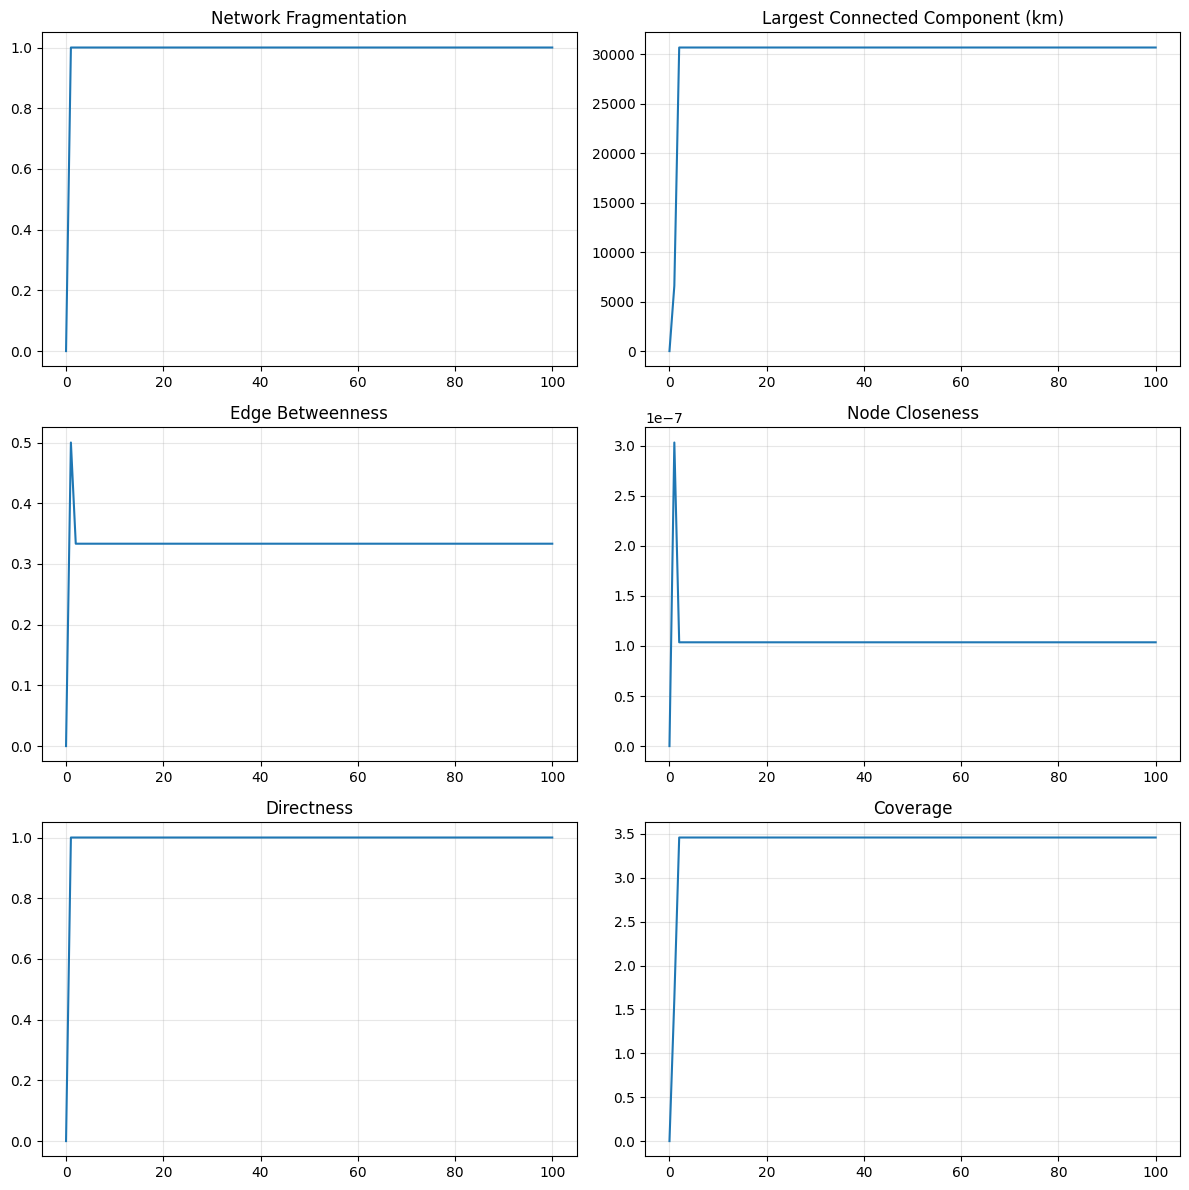

In [25]:
chosen_heuristic = 'L2S'
chosen_locality = "MASTER"

optimised_locality_heuristic_df = optimised_graph_results_df[
    (optimised_graph_results_df['heuristic'] == chosen_heuristic) &
    (optimised_graph_results_df['locality'] == chosen_locality)
]
Plotting.plot_metrics(optimised_locality_heuristic_df)

In [26]:
#G_locality= graph_util.make_locality_subgraph(G_master,chosen_locality)
#plotting.plot_directionality(G_master)

In [27]:
edges = list(G_master.edges(keys=True, data=True))
u, v, k, data = edges[0]
print(u, v, k)
display(data)

197798 1497329566 0


{'osmid': [139266489, 1182920597],
 'oneway': True,
 'highway': 'primary',
 'name': 'Triq l-Imġarr',
 'name:en': 'Mġarr Road',
 'reversed': False,
 'length': 8402692.93419991,
 'geometry': <LINESTRING (435890.692 3986839.052, 435904.483 3986833.56, 435927.949 39868...>,
 'car_allowed': True,
 'bike_allowed': False,
 'grade': -0.038010328418853705,
 'grade_abs': 0.038010328418853705,
 'car_lanes': 1,
 'bike_lanes': 0,
 'infra_type': 'car',
 'safety': 'dangerous',
 'risk_factor': 4.0,
 'reallocatable': False,
 'region': 'Reġjun Għawdex',
 'locality': 'Għajnsielem',
 'parallel_count': 1}

In [28]:
missing = [(u, v, k) for u, v, k, d in G_master.edges(keys=True, data=True) if d.get("width") is None]
print("Edges without width:", len(missing), "/", G_master.number_of_edges(), f"({100*len(missing)/G_master.number_of_edges():.2f}%)")
# show up to 10 examples
print("Examples:", missing[:10])

Edges without width: 12343 / 12415 (99.42%)
Examples: [(197798, 1497329566, 0), (197798, 158611509, 0), (197798, 13169274834, 0), (1497329566, 1494342639, 0), (1497329566, 158591473, 0), (158611509, 60794838, 0), (158611509, 197798, 0), (158611509, 158611353, 0), (158611509, 3525042262, 0), (13169274834, 197798, 0)]


In [29]:
G_master[4552382185][1534377155][0]

{'osmid': 1285629834,
 'oneway': False,
 'highway': 'secondary',
 'reversed': True,
 'length': 495035.85579473013,
 'geometry': <LINESTRING (437817.93 3988021.86, 437815.845 3988022.562, 437813.639 398802...>,
 'car_allowed': True,
 'bike_allowed': False,
 'grade': -0.0285125315543621,
 'grade_abs': 0.0285125315543621,
 'car_lanes': 1,
 'bike_lanes': 0,
 'infra_type': 'car',
 'safety': 'dangerous',
 'risk_factor': 4.0,
 'reallocatable': False,
 'region': 'Reġjun Għawdex',
 'locality': 'Il-Qala',
 'parallel_count': 1}

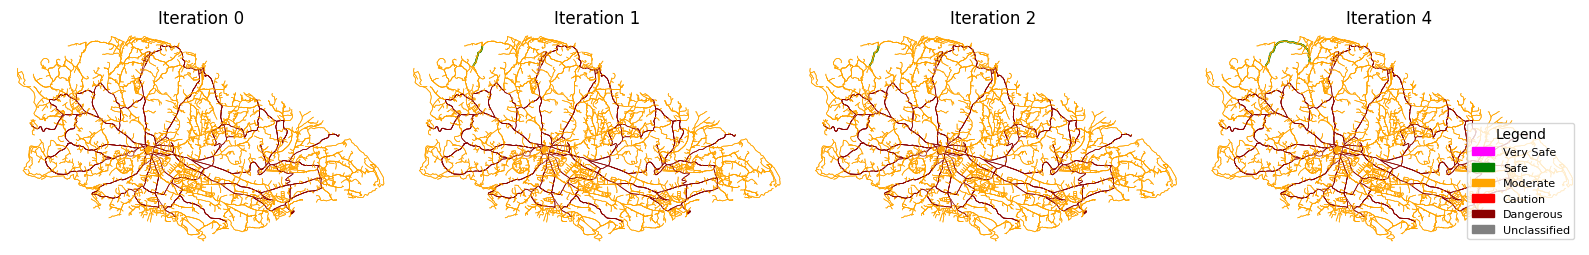

In [30]:
diff_log_series = optimised_locality_heuristic_df["diff_log"]
diff_log = diff_log_series.explode().dropna().tolist()

#plotting.plot_snapshots(graph_util.make_bikeable_subgraph(G_master), diff_log, num_snapshots=4, show_classification=False)
Plotting.plot_snapshots(G_master, diff_log, num_snapshots=4, show_classification=True)


#TODO there seems to be multiple edges beneath each other?

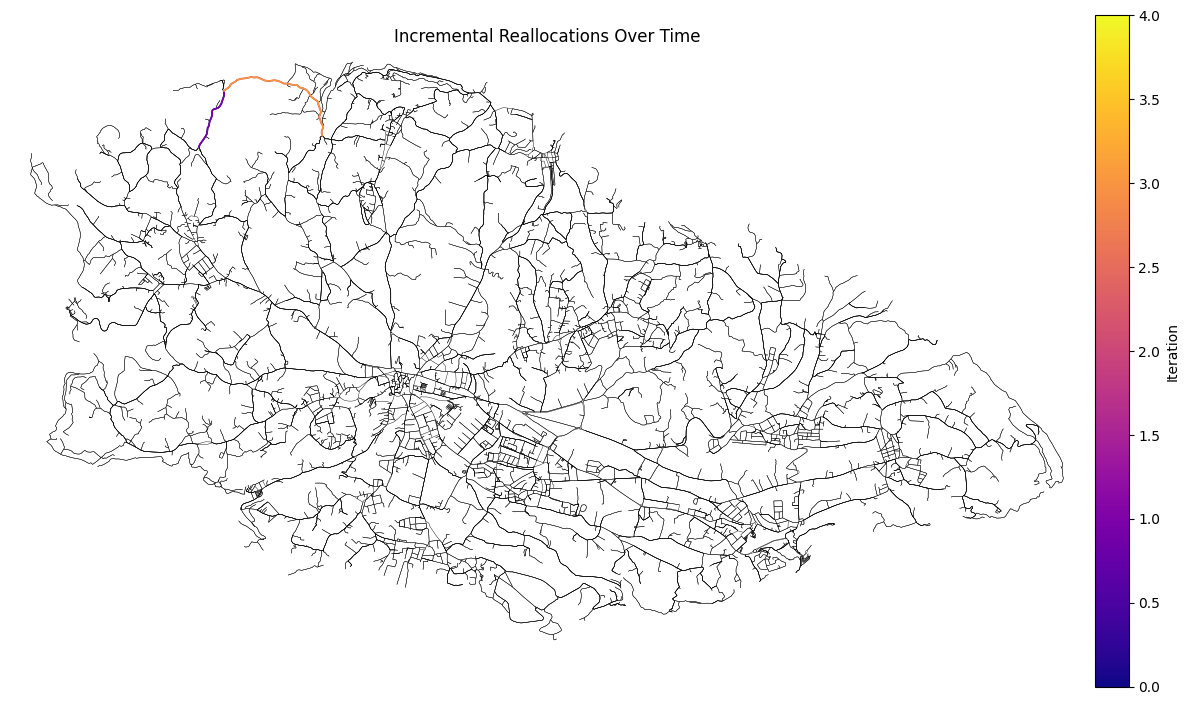

In [31]:
Plotting.plot_network_evolution(G_master, diff_log)

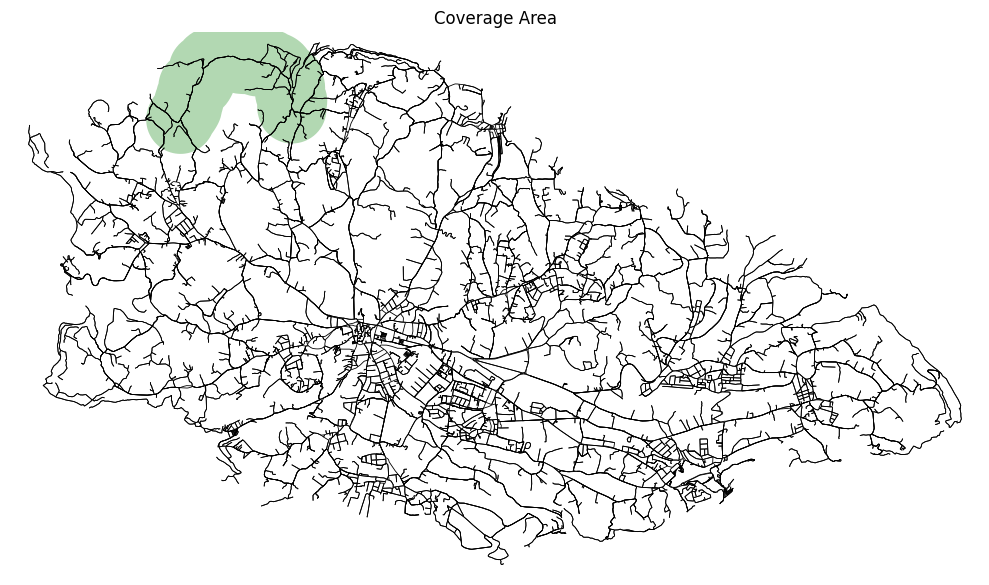

In [32]:
union_geom = optimised_locality_heuristic_df["union_geom"].iloc[-1]
Plotting.plot_coverage(G_master, union_geom)

# OD Matrix Generation

Origin and Destination valid sample region and points

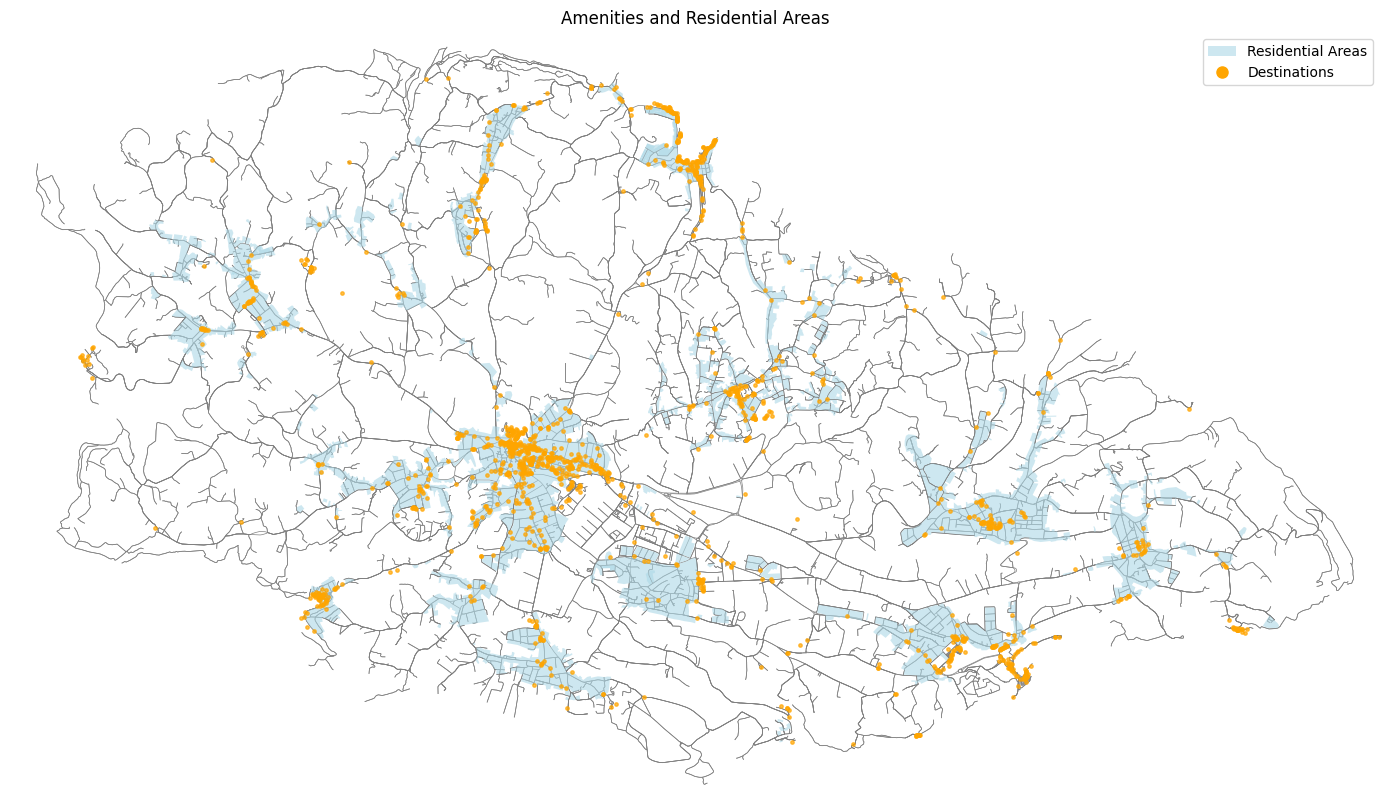

In [40]:
# https://wiki.openstreetmap.org/wiki/Key:amenity
gdf_destinations = ox.features_from_place(
    LOCATION,
    tags={    
        "amenity": True,   # schools, hospitals, cafes, etc.
        "shop": True,      # retail, services, supermarkets, etc.
        "office": True     # workplaces (IT, government, companies, etc.)
        }
)

gdf_residential = ox.features_from_place(
    LOCATION,
    tags={"landuse": "residential"}
)

gdf_destinations = gdf_destinations.to_crs(G_master.graph["crs"])
gdf_destinations = ODGeneration.prepare_destinations_with_weights(gdf_destinations, ODGeneration.DESTINATION_WEIGHTS)
gdf_residential = gdf_residential.to_crs(G_master.graph["crs"])


Plotting.plot_OD_points(
    G_master,
    gdf_residential=gdf_residential,
    gdf_destinations=gdf_destinations,
    title="Amenities and Residential Areas",)


- Sample origins from residential areas (weighted by area or building count)
- Sample destinations from amenities (weighted by amenity type)
- Apply cycling feasibility constraint (distance cutoff or decay)
- Repeat X times to build OD flows

- Add secondary pure random trips

Investigating the different amenities and their frequency

In [43]:
gdf_destinations.head()

print("dest_type:")
display(gdf_destinations["dest_type"].value_counts())

print("dest_subtype:")
display(gdf_destinations["dest_subtype"].value_counts())

dest_type:


dest_type
amenity    1158
shop        258
office       19
Name: count, dtype: int64

dest_subtype:


dest_subtype
bench                      358
restaurant                 159
parking                     99
waste_basket                71
place_of_worship            46
                          ... 
college                      1
prison                       1
agrarian                     1
educational_institution      1
clinic                       1
Name: count, Length: 130, dtype: int64

geometry dest_type  \
element id                                                     
node    156206003    POINT (431788.823 3987178.43)   amenity   
        158573572   POINT (431316.288 3989261.895)   amenity   
        158646190   POINT (436673.017 3988079.598)   amenity   
        160284765    POINT (430280.84 3987902.254)   amenity   
        171167035   POINT (429793.545 3992105.272)   amenity   
...                                            ...       ...   
way     1455497043  POINT (434410.625 3988420.713)   amenity   
        1455956907   POINT (437279.77 3987907.182)   amenity   
        1457346211  POINT (433727.622 3987930.872)      shop   
        1457371865  POINT (436593.425 3986915.469)   amenity   
        1457371867  POINT (435826.616 3986906.894)   amenity   

                        dest_subtype  weight  
element id                                    
node    156206003   place_of_worship     1.0  
        158573572               fuel     1.0  
        158646190         restaurant     2.5  
        160284765         biergarten     1.0  
        171167035            parking     1.0  
...                              ...     ...  
way     1455497043           parking     1.0  
        1455956907           shelter     1.0  
        1457346211           chemist     1.0  
        1457371865           parking     1.0  
        1457371867           parking     1.0  

[1435 rows x 4 columns]

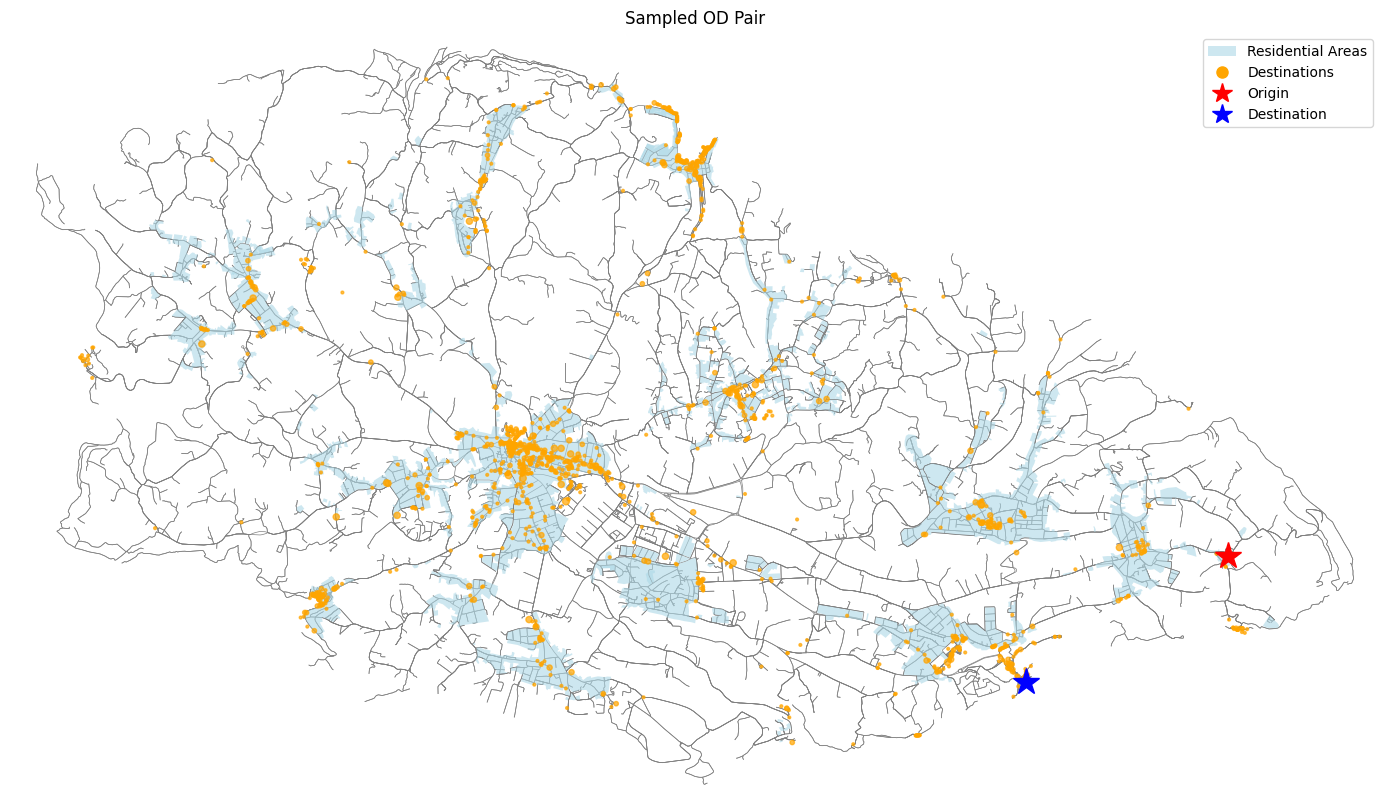

In [44]:
origin_pt = ODGeneration.sample_point_from_regions_weighted(gdf_residential)


display(gdf_destinations)

destination_pt = ODGeneration.sample_destination(origin_pt, gdf_destinations)

# Plot the point on the graph
Plotting.plot_OD_points( 
    G_master,
    gdf_residential=gdf_residential,
    gdf_destinations=gdf_destinations,
    destination_size_col="weight",
    origin_point=origin_pt,
    destination_point=destination_pt,
    title="Sampled OD Pair",
)
